In [4]:
import sys
print(sys.executable)

c:\Users\Hp\anaconda3\python.exe


In [7]:
import sys
!{sys.executable} -m pip install xgboost shap

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 1.1 MB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   ------------- -------------------------- 1/3 [xgboost]
   ------------- -------------------------- 1/3 [xgboost]
   ------------- -------------------------- 1/3 [xgboost]
   ------------- -------------------------- 1/3 [xgboost]
   -----------

In [8]:
import xgboost
import shap

print("Libraries installed successfully")

Libraries installed successfully


In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

import xgboost as xgb
import shap

In [10]:
df = pd.read_csv("../data/insurance_data.csv")

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [11]:
claims_df = df[df['TotalClaims'] > 0].copy()

claims_df.shape

(1535, 21)

In [12]:
features = [
    'Age',
    'Gender',
    'Province',
    'VehicleType',
    'AnnualPremium',
    'CustomValueEstimate',
    'RiskScore',
    'AutoMake'
]

target = 'TotalClaims'

In [14]:
df = pd.read_csv("../data/insurance_data.csv")
df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [15]:
claims_df = df[df['TotalClaims'] > 0].copy()

In [16]:
features = [
    'Age',
    'Gender',
    'Province',
    'VehicleType',
    'AnnualPremium',
    'CustomValueEstimate',
    'RiskScore',
    'AutoMake'
]

target = 'TotalClaims'

In [17]:
X = claims_df[features]
y = claims_df[target]

In [18]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print(categorical_cols)
print(numerical_cols)

Index(['Gender', 'Province', 'VehicleType', 'AutoMake'], dtype='object')
Index(['Age', 'AnnualPremium', 'CustomValueEstimate', 'RiskScore'], dtype='object')


In [20]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [21]:
features = [
    'Age',
    'Gender',
    'Province',
    'VehicleType',
    'AnnualPremium',
    'CustomValueEstimate',
    'RiskScore',
    'AutoMake'
]

target = 'TotalClaims'

X = claims_df[features]
y = claims_df[target]

In [22]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

In [23]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [26]:
features = [
    'Age',
    'Gender',
    'Province',
    'VehicleType',
    'AnnualPremium',
    'CustomValueEstimate',
    'RiskScore',
    'AutoMake'
]

target = 'TotalClaims'

X = claims_df[features]
y = claims_df[target]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_test)

In [29]:
X_train
X_test
y_train
y_test

7530    10334.0
436     15340.0
2168     5239.0
6869     6677.0
8877     1912.0
         ...   
7683    10045.0
5609    15063.0
9848    12035.0
1455     4011.0
6431    11589.0
Name: TotalClaims, Length: 307, dtype: float64

In [30]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

In [31]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest RMSE: 5510.0339079446985
Random Forest R²: 0.14161064687266656


In [32]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train_processed, y_train)

xgb_preds = xgb_model.predict(X_test_processed)

In [33]:
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R²:", xgb_r2)

XGBoost RMSE: 5655.054286690256
XGBoost R²: 0.09583157617058025


In [35]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

linear_preds = linear_model.predict(X_test)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_preds))
linear_r2 = r2_score(y_test, linear_preds)

print(linear_rmse, linear_r2)

5259.326617351498 0.21794721983665621


In [36]:
rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print(rf_rmse, rf_r2)

5510.0339079446985 0.14161064687266656


In [37]:
xgb_preds = xgb_model.predict(X_test_processed)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print(xgb_rmse, xgb_r2)

5655.054286690256 0.09583157617058025


In [38]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [linear_rmse, rf_rmse, xgb_rmse],
    "R2": [linear_r2, rf_r2, xgb_r2]
})

results

,Model,RMSE,R2
0,Linear Regression,5259.326617,0.217947
1,Random Forest,5510.033908,0.141611
2,XGBoost,5655.054287,0.095832


In [39]:
print("checkpoint saved")

checkpoint saved


In [40]:
import shap

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test_processed)

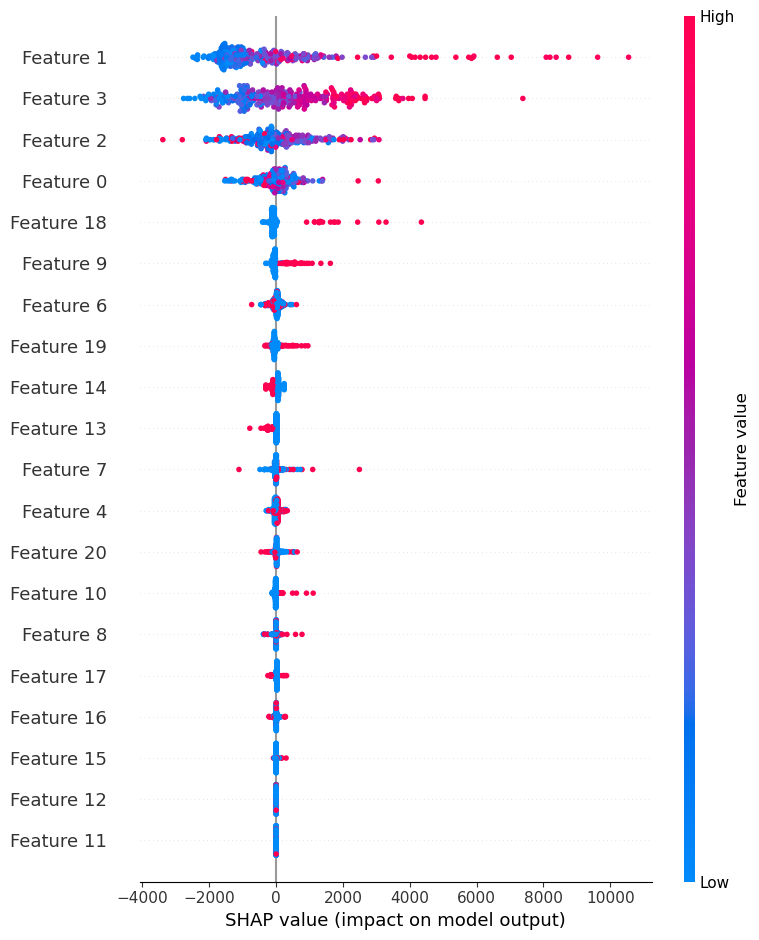

In [41]:
shap.summary_plot(shap_values, X_test_processed)

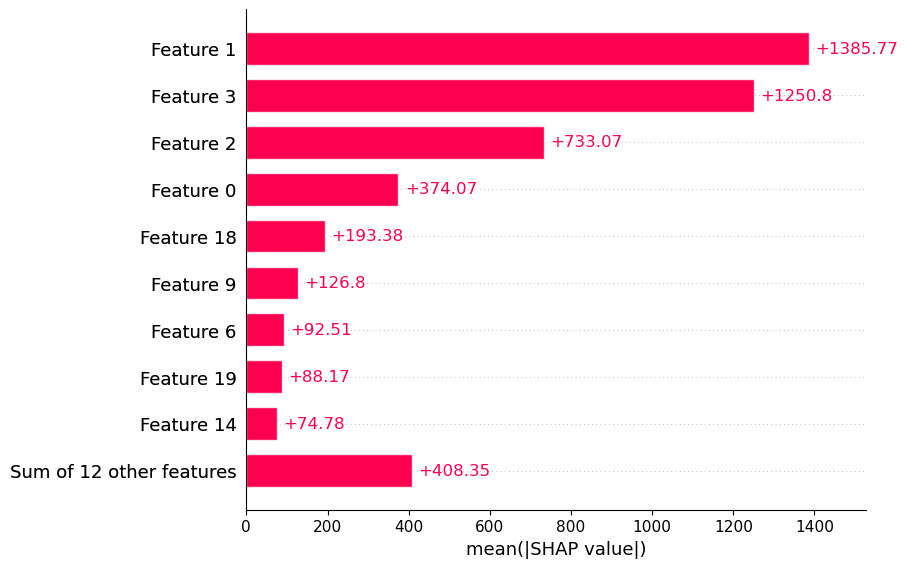

In [42]:
shap.plots.bar(shap_values)

SHAP Insights Interpretation
Features with highest impact on claim severity are the strongest risk drivers.
Higher RiskScore increases predicted claim amount.
Certain VehicleTypes show higher claim severity.
Higher CustomValueEstimate leads to higher predicted losses.
Age and vehicle characteristics significantly influence insurance risk.